In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FILES = [
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.f5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.Inosine.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m1y.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.m7g.tsv",
    "/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv",
]

IN_DIR  = os.path.dirname(FILES[0])
OUT_DIR = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig21"
os.makedirs(OUT_DIR, exist_ok=True)

POS_IS_1BASED = True

PROB_TH = 0.9
MIN_DEPTH = 5
SITE_POS_FRAC = 0.5

pos_col = 1
kmer_col = 2
prob_col = 5
K = 5

missing = [p for p in FILES if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("这些文件不存在：\n" + "\n".join(missing))

print("OUT_DIR =", OUT_DIR)
print("n_files =", len(FILES))



OUT_DIR = /mnt/sunxh/sunxh/wattmamba/new_result/supfig21
n_files = 10


In [2]:
def collect_positive_sites(WT: str,
                           PROB_TH=0.9, MIN_DEPTH=5, SITE_POS_FRAC=0.5,
                           pos_col=1, prob_col=5, kmer_col=2, K=5):
    """
    sid=transcript|pos|kmer 聚合，返回阳性位点列表：
      [(tx_nov, pos_int), ...]
    """
    site_dict = {}  # sid -> [n_hi, n_all]
    with open(WT, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) <= max(pos_col, prob_col, kmer_col):
                continue

            tid_raw = parts[0]
            pos_str = parts[pos_col]
            kmer = parts[kmer_col].upper()
            if len(kmer) != K:
                continue

            try:
                pos = int(pos_str)
            except ValueError:
                continue
            if not POS_IS_1BASED:
                pos += 1

            try:
                prob = float(parts[prob_col])
            except ValueError:
                continue

            sid = "|".join([tid_raw, str(pos), kmer])
            if sid not in site_dict:
                site_dict[sid] = [0, 0]
            if prob > PROB_TH:
                site_dict[sid][0] += 1
            site_dict[sid][1] += 1

    pos_sites = []
    for sid, (n_hi, n_all) in site_dict.items():
        if n_all < MIN_DEPTH:
            continue
        if (n_hi / n_all) < SITE_POS_FRAC:
            continue
        tid_raw, pos_str, _ = sid.split("|")
        tx_nov = tid_raw.split(".")[0]
        pos_sites.append((tx_nov, int(pos_str)))

    return pos_sites


In [ ]:
paths = FILES  
if len(paths) == 0:
    raise ValueError("FILES 为空")
def mod_name_from_path(p):
    base = os.path.basename(p)
    parts = base.split(".")
    return parts[-2] if len(parts) >= 3 else os.path.splitext(base)[0]

mod2sites = {} 
rows = []

for p in paths:
    mod = mod_name_from_path(p)

    pos_sites = collect_positive_sites(
        p,
        PROB_TH=PROB_TH, MIN_DEPTH=MIN_DEPTH, SITE_POS_FRAC=SITE_POS_FRAC,
        pos_col=pos_col, prob_col=prob_col, kmer_col=kmer_col, K=K
    )

    s = set([f"{tx}|{pos}" for tx, pos in pos_sites])
    mod2sites[mod] = s

    rows.append({"mod": mod, "n_sites": len(s), "file": p})

counts = (pd.DataFrame(rows)
          .sort_values("n_sites", ascending=False)
          .reset_index(drop=True))

counts_path = os.path.join(OUT_DIR, "site_counts.filtered.csv")
counts.to_csv(counts_path, index=False)

counts


,mod,n_sites,file
0,Inosine,17908,/mnt/sunxh/sunxh/project/HEYA8/rep1.Inosine.tsv
1,hm5c,13661,/mnt/sunxh/sunxh/project/HEYA8/rep1.hm5c.tsv
2,psu,12329,/mnt/sunxh/sunxh/project/HEYA8/rep1.psu.tsv
3,m5u,1668,/mnt/sunxh/sunxh/project/HEYA8/rep1.m5u.tsv
4,m7g,1269,/mnt/sunxh/sunxh/project/HEYA8/rep1.m7g.tsv
5,f5c,1154,/mnt/sunxh/sunxh/project/HEYA8/rep1.f5c.tsv
6,m5c,1008,/mnt/sunxh/sunxh/project/HEYA8/rep1.m5c.tsv
7,m6a,634,/mnt/sunxh/sunxh/project/HEYA8/rep1.m6a.tsv
8,m1a,524,/mnt/sunxh/sunxh/project/HEYA8/rep1.m1a.tsv
9,m1y,469,/mnt/sunxh/sunxh/project/HEYA8/rep1.m1y.tsv


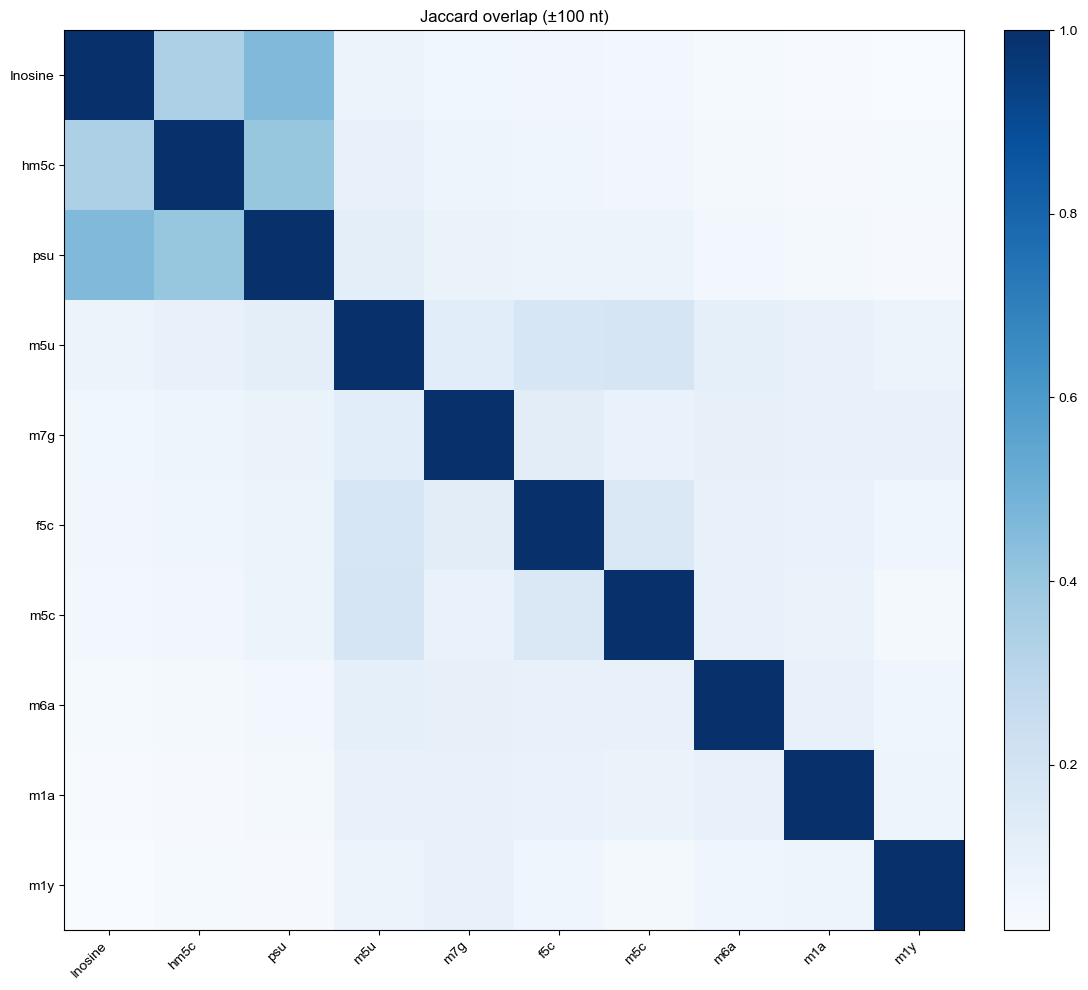

'/mnt/sunxh/sunxh/wattmamba/new_result/supfig21/mods_jaccard_heatmap_pm100nt_exclude0.pdf'

In [5]:
WINDOW = 100
import matplotlib as mpl

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"]  = 42

mod2txpos = {}
for mod, sites in mod2sites.items():
    txpos = {}
    for s in sites:  # s = "tx|pos"
        tx, pos = s.split("|")
        pos = int(pos)
        txpos.setdefault(tx, []).append(pos)
    for tx in txpos:
        txpos[tx].sort()
    mod2txpos[mod] = txpos

WINDOW = 100

def match_count_within_window_exclude_samepos(txposA, txposB, w=10):
    """
    计算在±w内的一对一匹配数，但排除同一位置(|d|=0)：
      只统计 1 <= |posA-posB| <= w
    """
    matches = 0
    common_txs = set(txposA.keys()) & set(txposB.keys())
    for tx in common_txs:
        a = txposA[tx]
        b = txposB[tx]
        i = j = 0
        while i < len(a) and j < len(b):
            d = a[i] - b[j]
            ad = abs(d)

            if ad == 0:
                i += 1
                j += 1
                continue

            if ad <= w:
                matches += 1
                i += 1
                j += 1
            elif d < -w:
                i += 1
            else:
                j += 1
    return matches

mods = list(counts["mod"])
n = len(mods)
from matplotlib.colors import LinearSegmentedColormap

c1 = (95/255, 95/255, 243/255)     # rgb(95, 95, 243)  -> #5f5ff3
c2 = (184/255, 113/255, 255/255)   # rgb(184, 113, 255)-> #b871ff
cmap_purple = LinearSegmentedColormap.from_list("purple_grad", [c1, c2], N=256)

J = np.zeros((n, n), float)
for i, a in enumerate(mods):
    A_txpos = mod2txpos.get(a, {})
    A_n = sum(len(v) for v in A_txpos.values())
    for j, b in enumerate(mods):
        if i == j:
            J[i, j] = 1.0
            continue
        B_txpos = mod2txpos.get(b, {})
        B_n = sum(len(v) for v in B_txpos.values())

        inter = match_count_within_window_exclude_samepos(A_txpos, B_txpos, w=WINDOW)
        union = A_n + B_n - inter
        J[i, j] = inter / union if union else 0.0

fig, ax = plt.subplots(figsize=(0.7*n + 4, 0.7*n + 3))
im = ax.imshow(J, aspect="equal", cmap="Blues")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(mods, rotation=45, ha="right")
ax.set_yticklabels(mods)
ax.set_title(f"Jaccard overlap (±{WINDOW} nt)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

out_png = os.path.join(OUT_DIR, f"mods_jaccard_heatmap_pm{WINDOW}nt_exclude0.pdf")
fig.savefig(out_png, dpi=1200,bbox_inches='tight')
plt.show()
plt.close(fig)
out_png


In [6]:
top_k = 3
pairs = []

for i, a in enumerate(mods):
    A = mod2sites[a]
    for j, b in enumerate(mods):
        if a == b:
            continue
        B = mod2sites[b]
        inter = len(A & B)
        union = len(A | B)
        jac = inter / union if union else 0.0
        pairs.append({
            "mod": a, "other": b,
            "jaccard": jac,
            "intersect": inter,
            "union": union
        })

pairs_df = pd.DataFrame(pairs)
top_df = (pairs_df.sort_values(["mod", "jaccard"], ascending=[True, False])
          .groupby("mod", as_index=False)
          .head(top_k)
          .sort_values(["mod", "jaccard"], ascending=[True, False])
          .reset_index(drop=True))

out_csv = os.path.join(OUT_DIR, "top_overlap_per_mod.csv")
top_df.to_csv(out_csv, index=False)

top_df


,mod,other,jaccard,intersect,union
0,Inosine,m6a,0.009473,174,18368
1,Inosine,m1a,0.006168,113,18319
2,Inosine,hm5c,0.000000,0,31569
3,f5c,m5c,0.116159,225,1937
4,f5c,hm5c,0.021865,317,14498
5,f5c,Inosine,0.000000,0,19062
6,hm5c,f5c,0.021865,317,14498
7,hm5c,m5c,0.011516,167,14502
8,hm5c,Inosine,0.000000,0,31569
9,m1a,m6a,0.367178,311,847


In [7]:
import pandas as pd
import os

rows = []
for i, a in enumerate(mods):
    A_txpos = mod2txpos.get(a, {})
    nA = sum(len(v) for v in A_txpos.values())
    for j, b in enumerate(mods):
        B_txpos = mod2txpos.get(b, {})
        nB = sum(len(v) for v in B_txpos.values())

        if i == j:
            inter = nA
            union = nA
            jac = 1.0 if union else 0.0
        else:
            inter = match_count_within_window_exclude_samepos(A_txpos, B_txpos, w=WINDOW)
            union = nA + nB - inter
            jac = inter / union if union else 0.0

        rows.append({
            "modA": a,
            "modB": b,
            "nA": nA,
            "nB": nB,
            "intersect": inter,
            "union": union,
            "jaccard": jac
        })

pair_df = pd.DataFrame(rows)

out_csv = os.path.join(OUT_DIR, f"jaccard_pairs_pm{WINDOW}nt_exclude0.csv")
pair_df.to_csv(out_csv, index=False, float_format="%.6f")

out_csv


'/mnt/sunxh/sunxh/wattmamba/new_result/supfig21/jaccard_pairs_pm100nt_exclude0.csv'

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ---- paths ----
in_txt = "/mnt/sunxh/sunxh/project/H9/top30_gene_counts.tsv"  # will write this from your pasted output if you want
out_png = "/mnt/sunxh/sunxh/project/H9/top30_gene_mod_counts_bar.png"
out_pdf = "/mnt/sunxh/sunxh/project/H9/top30_gene_mod_counts_bar.pdf"
# ---- If you don't already have a TSV file, paste the lines into a triple-quoted string below ----
raw = """NFE2L1 ENSG00000082641 72
VCAN ENSG00000038427 68
MYH10 ENSG00000133026 61
SON ENSG00000159140 50
CNOT1 ENSG00000125107 47
STAU1 ENSG00000124214 46
VCAN-AS1 ENSG00000249835 46
FLNA ENSG00000196924 45
GNAS ENSG00000087460 45
MATR3 ENSG00000280987 44
ILF3 ENSG00000129351 43
MATR3 ENSG00000015479 43
WDR6 ENSG00000178252 43
COL18A1 ENSG00000182871 42
CPNE1 ENSG00000214078 41
FBXO11 ENSG00000138081 41
HDLBP ENSG00000115677 41
SHC1 ENSG00000160691 41
AL109827.1 ENSG00000272897 40
SEPT9 ENSG00000184640 40
ZNF146 ENSG00000167635 39
ZNF565 ENSG00000196357 39
HNRNPF ENSG00000169813 38
RBM12 ENSG00000244462 38
TBC1D16 ENSG00000167291 38
ADAR ENSG00000160710 37
IPO5 ENSG00000065150 37
ERBB2 ENSG00000141736 36
NLGN4X ENSG00000146938 36
EIF4G1 ENSG00000114867 35
"""

# Parse
rows = []
for line in raw.strip().splitlines():
    parts = line.strip().split()
    if len(parts) < 3:
        continue
    gene = parts[0]
    gid = parts[1]
    cnt = int(parts[2])
    rows.append((gene, gid, cnt))
df = pd.DataFrame(rows, columns=["gene_name", "gene_id", "count"])
df = df.sort_values("count", ascending=True).reset_index(drop=True)

# Save TSV for provenance
df.sort_values("count", ascending=False).to_csv(in_txt, sep="\t", index=False)

# Plot
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 9
plt.rcParams["axes.linewidth"] = 0.8

fig = plt.figure(figsize=(6.2, 6.0), dpi=1200)
plt.barh(df["gene_name"], df["count"])
plt.xlabel("Number of modified sites")
plt.ylabel("Gene")
plt.title("Top genes by modified-site count (WattmaMod)")
plt.tight_layout()

# Save
fig.savefig(out_png, dpi=1200)
fig.savefig(out_pdf)
plt.show()
(out_png, out_pdf, in_txt)



('/mnt/sunxh/sunxh/project/H9/top30_gene_mod_counts_bar.png',
 '/mnt/sunxh/sunxh/project/H9/top30_gene_mod_counts_bar.pdf',
 '/mnt/sunxh/sunxh/project/H9/top30_gene_counts.tsv')